In [1]:
from keras.utils import image_dataset_from_directory
from keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import os
import shutil
from PIL import Image

2025-07-28 17:10:12.809486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753722613.010696      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753722613.074774      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_ds=image_dataset_from_directory('/kaggle/input/spanish-dataset/train_oversampling',seed=42,batch_size=16,image_size=(363,360))
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('/kaggle/input/spanish-dataset/val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
test_ds=image_dataset_from_directory('/kaggle/input/spanish-dataset/test',seed=42,batch_size=16,image_size=(363,360),label_mode='int')

Found 18640 files belonging to 8 classes.


I0000 00:00:1753722636.009727      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2564 files belonging to 8 classes.
Found 2569 files belonging to 8 classes.


In [3]:
train_ds=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds=test_ds.map(lambda x,y:(preprocess_input(x),y))

In [4]:
base_model=VGG16(weights='imagenet',include_top=False)
base_model.trainable=False
# for layer in base_model.layers[:8]:
#     layer.trainable = True
# for layer in base_model.layers[8:]:
#     layer.trainable = False
inputs=Input(shape=(363,360,3))
x=Resizing(224,224)(inputs)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

  1: input_layer                              — Trainable: False
  2: block1_conv1                             — Trainable: False
  3: block1_conv2                             — Trainable: False
  4: block1_pool                              — Trainable: False
  5: block2_conv1                             — Trainable: False
  6: block2_conv2                             — Trainable: False
  7: block2_pool                              — Trainable: False
  8: block3_conv1                             — Trainable: False
  9: block3_conv2                             — Trainable: False
 10: block3_conv3                             — Trainable: False
 11: block3_pool                              — Trainable: False
 12: block4_conv1                             — Trainable: False
 13: block4_conv2                             — Trainable: False
 14: block4_conv3                             — Trainable: False
 15: block4_pool                              — Trainable: False
 16: block5_conv1        

In [6]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 363, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,768,904 (60.15 MB)

 Trainable params: 1,054,216 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=10)

Epoch 1/10


I0000 00:00:1753722830.557896     102 service.cc:148] XLA service 0x7f086040f6f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753722830.558585     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753722831.007293     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1165 ━━━━━━━━━━━━━━━━━━━━ 2:40 138ms/step - accuracy: 0.1250 - loss: 2.1549

I0000 00:00:1753722836.958418     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1165/1165 ━━━━━━━━━━━━━━━━━━━━ 83s 63ms/step - accuracy: 0.5657 - loss: 1.1408 - val_accuracy: 0.8436 - val_loss: 0.4586
Epoch 2/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 69s 59ms/step - accuracy: 0.8211 - loss: 0.5086 - val_accuracy: 0.8569 - val_loss: 0.4049
Epoch 3/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 68s 58ms/step - accuracy: 0.8424 - loss: 0.4383 - val_accuracy: 0.8697 - val_loss: 0.3696
Epoch 4/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 68s 58ms/step - accuracy: 0.8606 - loss: 0.4006 - val_accuracy: 0.8764 - val_loss: 0.3606
Epoch 5/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 68s 58ms/step - accuracy: 0.8748 - loss: 0.3597 - val_accuracy: 0.8830 - val_loss: 0.3313
Epoch 6/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 67s 58ms/step - accuracy: 0.8752 - loss: 0.3521 - val_accuracy: 0.8666 - val_loss: 0.3652
Epoch 7/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 67s 58ms/step - accuracy: 0.8864 - loss: 0.3244 - val_accuracy: 0.9056 - val_loss: 0.2765
Epoch 8/10
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 67s 58ms/step - accuracy: 0.8935 - loss: 0.30

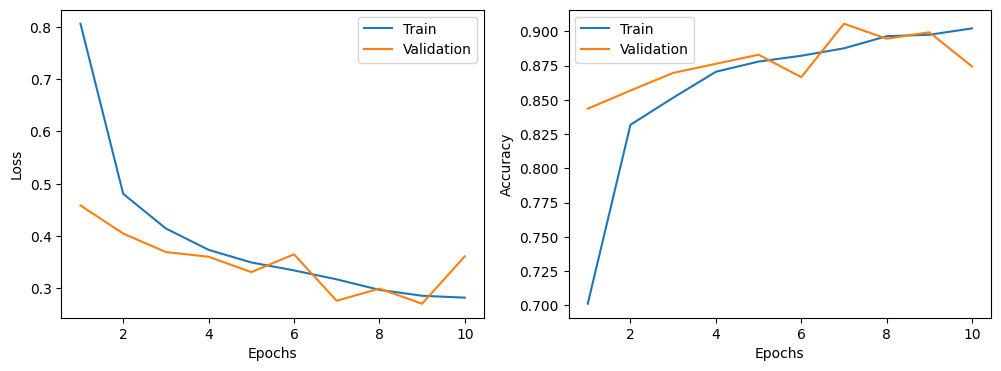

In [9]:
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [10]:
for layer in base_model.layers[-4:]:
    layer.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [11]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

  1: input_layer                              — Trainable: False
  2: block1_conv1                             — Trainable: False
  3: block1_conv2                             — Trainable: False
  4: block1_pool                              — Trainable: False
  5: block2_conv1                             — Trainable: False
  6: block2_conv2                             — Trainable: False
  7: block2_pool                              — Trainable: False
  8: block3_conv1                             — Trainable: False
  9: block3_conv2                             — Trainable: False
 10: block3_conv3                             — Trainable: False
 11: block3_pool                              — Trainable: False
 12: block4_conv1                             — Trainable: False
 13: block4_conv2                             — Trainable: False
 14: block4_conv3                             — Trainable: False
 15: block4_pool                              — Trainable: False
 16: block5_conv1        

In [12]:
optim=Adam(1e-5)
model.compile(loss='sparse_categorical_crossentropy',optimizer=optim,metrics=['accuracy'])

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 363, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,768,904 (60.15 MB)

 Trainable params: 8,133,640 (31.03 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=5,             # wait 5 epochs before stopping
    mode='min',min_delta=0.001,
    restore_best_weights=True  # keep the best weights
)
reduceLR=ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=3,
                           min_delta=0.001,cooldown=4)

In [15]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=100,callbacks=[early_stopping,reduceLR])

Epoch 1/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - accuracy: 0.9269 - loss: 0.2196 - val_accuracy: 0.9618 - val_loss: 0.1199 - learning_rate: 1.0000e-05
Epoch 2/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.9671 - loss: 0.0995 - val_accuracy: 0.9559 - val_loss: 0.1455 - learning_rate: 1.0000e-05
Epoch 3/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.9789 - loss: 0.0638 - val_accuracy: 0.9501 - val_loss: 0.1676 - learning_rate: 1.0000e-05
Epoch 4/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.9849 - loss: 0.0450 - val_accuracy: 0.9676 - val_loss: 0.0998 - learning_rate: 1.0000e-05
Epoch 5/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.9856 - loss: 0.0428 - val_accuracy: 0.9626 - val_loss: 0.1380 - learning_rate: 1.0000e-05
Epoch 6/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.9912 - loss: 0.0256 - val_accuracy: 0.9711 - val_loss: 0.0926 - learning_rate: 1.0000e-05
Epoch 7/100
1165/1165 ━━━━━━━━━━━━

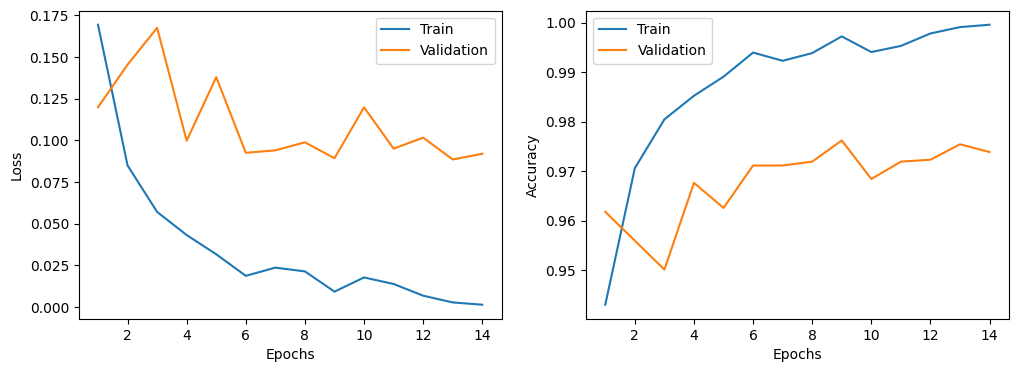

In [17]:
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [16]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.98      0.97      0.98       183
  eosinophil       0.99      1.00      0.99       468
erythroblast       0.98      0.95      0.97       233
          ig       0.97      0.91      0.94       435
  lymphocyte       0.97      0.97      0.97       183
    monocyte       0.93      0.95      0.94       214
  neutrophil       0.94      0.98      0.96       500
    platelet       0.99      0.99      0.99       353

    accuracy                           0.97      2569
   macro avg       0.97      0.97      0.97      2569
weighted avg       0.97      0.97      0.97      2569



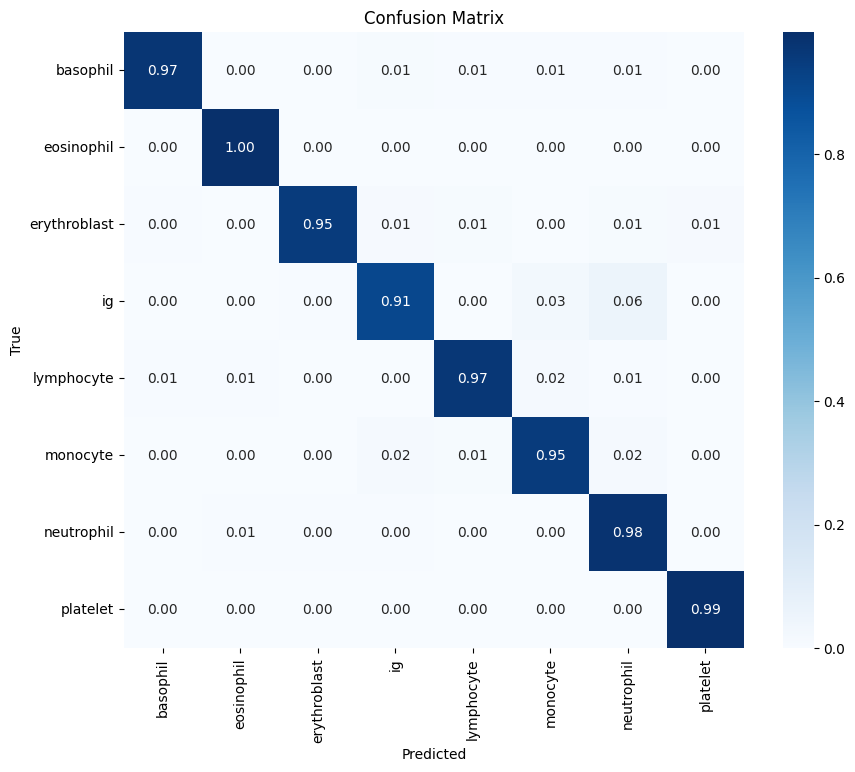

In [19]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [20]:
import pickle

with open('training_history_vgg_fine_tuning_lastLayers.pkl', 'wb') as f:
    pickle.dump(history_model.history, f)

model.save('vgg16_model_fine_tuning_lastLayers.h5')